In [1]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report 
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# Create a sample dataset
np.random.seed(42)
n_samples = 1000

data = {
    "glucose": np.random.normal(120, 30, n_samples),
    "blood_pressure":np.random.normal(80, 15, n_samples),
    "bmi" : np.random.normal(28, 7, n_samples),
    "age": np.random.randint(20, 80, n_samples)
}

# Create a target variable (diabetes: 1 = yes, 0 = np)
# Higher glucose, BMI, and age increase probability 

diabetes_probability = (
    (data["glucose"] - 120) /100 +
    (data["bmi"] - 28)/20 +
    (data["age"] - 50) /50

)

In [3]:
data["diabetes"] = (diabetes_probability + np.random.normal(0, 0.3, n_samples) > 0).astype(int)


In [4]:
df = pd.DataFrame(data)

In [9]:
# Step 01. Explore the data
print(f"Dataset shape: {df.shape}\n")
df.head()

Dataset shape: (1000, 5)



,glucose,blood_pressure,bmi,age,diabetes
0,134.901425,100.990332,23.273752,73,1
1,115.852071,93.869505,26.988369,47,0
2,139.430656,80.894456,22.453061,77,1
3,165.690896,70.295948,25.844269,49,1
4,112.975399,90.473350,14.744697,28,0


In [11]:
print(f"\nClass Distribution\n")
print(df["diabetes"].value_counts())


Class Distribution

diabetes
1    506
0    494
Name: count, dtype: int64


In [13]:
# Step 02. Split features and target 
X = df[["glucose", "blood_pressure", "bmi", "age"]]
y = df["diabetes"]

In [15]:
# Step 03. Split into training and testing sets (80 / 20)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.2,
    random_state=42, 
    stratify=y    # Prevent imbalanced splits
)

print(f"Training set size: {len(X_train)}")
print(f"Testing set size: {len(X_test)}")

Training set size: 800
Testing set size: 200


In [19]:
# Step 04. Scale the features (important for many algorithms) 
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [21]:
# Step 05. Train the model (Logistic Regression)
model = LogisticRegression(random_state = 42)
model.fit(X_train_scaled, y_train)

LogisticRegression(random_state=42)

In [33]:
# Step 06. Make predictions
y_pred = model.predict(X_test_scaled)
y_pred_proba = model.predict_proba(X_test_scaled)[:, 1]  #Probability of class 1

In [45]:
# Step 07. Evaluate the model
print(f"---Model Evalution ---")
print(f"Accuracy: {accuracy_score(y_test, y_pred):.3f}")
print(f"\n\n---Classification Report ---")
print(classification_report(y_test, y_pred))


---Model Evalution ---
Accuracy: 0.885


---Classification Report ---
              precision    recall  f1-score   support

           0       0.90      0.87      0.88        99
           1       0.88      0.90      0.89       101

    accuracy                           0.89       200
   macro avg       0.89      0.88      0.88       200
weighted avg       0.89      0.89      0.88       200



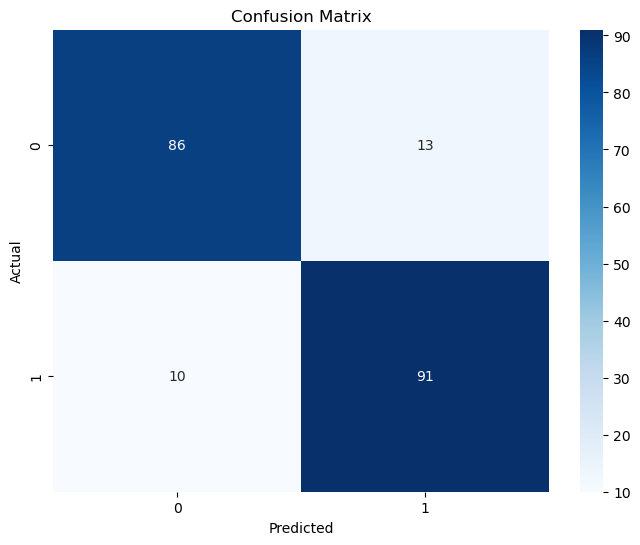

In [51]:
 # Confusion Matrix
cm  = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot = True, fmt = "d", cmap = "Blues")
plt.title("Confusion Matrix")
plt.ylabel("Actual")
plt.xlabel("Predicted")
plt.show()

In [63]:
# Step 8. Make predictions on new data
new_patient = np.array([[150, 90, 32, 55]])  # glucose, BP, BMI, age
new_patient_scaled = scaler.transform(new_patient)
prediction = model.predict(new_patient_scaled)
probability = model.predict_proba(new_patient_scaled)[0,1]

print(f"New patient prediction: {"Diabetes" if prediction[0] ==1 else "No Diabetes"}")
print(f"Probability of Diabetes: {probability:.2%}")



New patient prediction: Diabetes
Probability of Diabetes: 97.02%


/opt/anaconda3/lib/python3.12/site-packages/sklearn/base.py:493: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


```
Key Stepd Explained:

1) Data preparation: Load and organize your data

2) Train/Test Split: Seperate data so we can evaluate on unseen examples

3) Feature Scaling: Normalize features to have similar ranges

4) Model Training: Fit the model to learn patterns

5) Predictions: Use the model on new data

6) Evaluation: Measure performance with metrics



Important Metrics

1) Accuracy - Percentage of correct predictions

2) Precision - Of predicted positives, how many are actually positive?

3) Recall: of acual positives, how many did we catch?

4) F1 - Score: Harmonic mean of precision and recall

5) Confusion Matrix: Shows true positives, false positives, true negatives and false negatives

```